In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
# Load the dataset
data = pd.read_csv('StudentsPerformance.csv')
data.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# Check missing values
print("Missing values:")
print(data.isnull().sum())

# Rename columns
data.rename(columns={
    'gender': 'Gender',
    'race/ethnicity': 'Race',
    'parental level of education': 'Parental_Education',
    'lunch': 'Lunch',
    'test preparation course': 'Test_Prep',
    'math score': 'Math',
    'reading score': 'Reading',
    'writing score': 'Writing'
}, inplace=True)

data.head()


Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


,Gender,Race,Parental_Education,Lunch,Test_Prep,Math,Reading,Writing
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


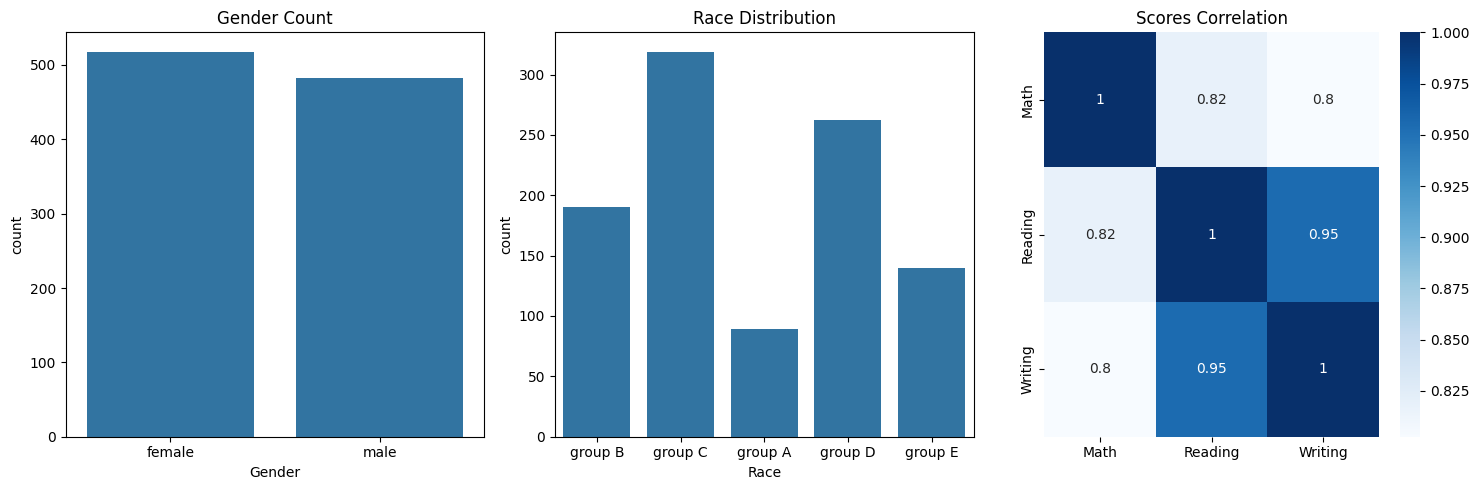

In [ ]:
plt.figure(figsize=(15, 5))

# Plot 1: Gender count
plt.subplot(1, 3, 1)
sns.countplot(x='Gender', data=data)
plt.title('Gender Count')

# Plot 2: Race count
plt.subplot(1, 3, 2)
sns.countplot(x='Race', data=data)
plt.title('Race Distribution')

# Plot 3: Correlation Heatmap
plt.subplot(1, 3, 3)
sns.heatmap(data[['Math', 'Reading', 'Writing']].corr(), annot=True, cmap='Blues')
plt.title('Scores Correlation')

plt.tight_layout()
plt.show()


In [ ]:
# Create Pass/Fail column
data['Average'] = (data['Math'] + data['Reading'] + data['Writing']) / 3
data['Pass'] = data['Average'].apply(lambda x: 1 if x >= 50 else 0)

X = data[['Math', 'Reading', 'Writing']]
y = data['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.985
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.99      0.99      0.99       173

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200

